# Trabajo practico n.º 1

Aca se encuentra el codigo utilizado para el analisis del modelo de kepler y del modelo con ajuste relativista.

In [3]:
#Librerias utilizadas
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Condiciones iniciales

In [ ]:
#Constantes
alpha = 1
delta = 0.5

#Variables
epsilon = 0.1
r_0 = alpha/(1+epsilon)

#Toleracias

# Modelo de Kepler

El modelo de kepler puede utilizar una ecuacion diferencial para mostrar las soluciones, sin embargo, al tener solucion exacta es mucho mas practico utilizarla tanto en precision como en menor cantidad de operaciones.

In [ ]:
# ---------------------------------
# Sistema de Kepler
# ---------------------------------
def sistema(y, alpha):
    u, v = y

    du = v
    dv = 1/alpha - u

    return [du, dv]

# ---------------------------------
# Solución exacta de Kepler
# ---------------------------------
def r_kepler(theta, alpha, eps):
    return alpha / (1 + eps * np.cos(theta))

### Dominio de $\theta$

Buscamos el dominio del parametro $\theta$.

Ya vimos que:

$$
r(\theta) = \frac{a}{1+\varepsilon\cos{\theta}}
$$

y para que tenga sentido fisico $r(\theta) \leq 0$

por lo que:

$$
1+\varepsilon\cos{\theta} > 0
$$

$$
\boxed{\theta > \arccos{\left(-\frac{1}{\varepsilon}\right)}}
$$

Entonces:

- Elipse: $\theta \in (0,2\pi)$
- Parabola: $\theta \in (-\pi, \pi)$
- Hiperbola: $\theta \in (\arccos{\left(-\frac{1}{\varepsilon}\right)}-, \arccos{\left(-\frac{1}{\varepsilon}\right)})$

In [ ]:
def dominio_kepler(eps, alpha):
    """
    Devuelve el dominio angular adecuado para la solución exacta de Kepler.
    """

    if eps > 1:
        theta_inf = np.arccos(-1 / eps)

        theta_eval = np.linspace(
            -theta_inf + 1e-4,
            theta_inf - 1e-4,
            5000
        )

    elif eps == 1:
        theta_eval = np.linspace(
            -0.99 * np.pi,
            0.99 * np.pi,
            5000
        )

    else:
        theta_eval = np.linspace(
            0,
            2 * np.pi,
            5000
        )

    return theta_eval

### Trayectoria

Apartir de los parametros, calcula el dominio, las soluciones en coordenadas polares y las convierte a cartesianas.

In [ ]:
def trayectoria_kepler(eps, alpha, r_kepler):
    """
    Devuelve (x, y) para la órbita exacta de Kepler.
    """

    theta = dominio_kepler(eps, alpha)

    r = r_kepler(theta, alpha, eps)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    return x, y


Debajo esta la trayectoria de kepler pero con un limite de renderizado para las hiperbolas que es donde tiende a infinito

In [27]:
def trayectoria_kepler(eps, alpha, r_kepler):

    theta = dominio_kepler(eps, alpha)
    r = r_kepler(theta, alpha, eps)

    r_max = 10 * alpha
    mask = np.isfinite(r) & (r < r_max)

    r = r[mask]
    theta = theta[mask]

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    return x, y

### Grafico

Funcion que genera grafico de la trayectoria de kepler a partir de los parametros

In [28]:
def graficar_orbitas(
    eccentricidades,
    alpha,
    r_kepler,
):
    """
    modo:
        - 'kepler'
        - 'relativista'
        - 'comparacion'
    """

    plt.figure(figsize=(8, 8))

    xs_plot = []
    ys_plot = []

    for eps in eccentricidades:

        xk, yk = trayectoria_kepler(
            eps,
            alpha,
            r_kepler
        )

        xs_plot.append(xk)
        ys_plot.append(yk)

        plt.plot(
            xk,
            yk,
            label=f"Kepler ε={eps}"
        )

    # -----------------------------
    # Sol en el origen
    # -----------------------------
    plt.scatter(
        0,
        0,
        s=80,
        label="Sol"
    )

    # -----------------------------
    # Ajuste automático de límites
    # -----------------------------
    xmin, xmax, ymin, ymax = (-15, 2, -4, 4)

    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

    plt.axis("equal")
    plt.grid(True)
    plt.legend()


    titulo = "Órbitas de Kepler"

    plt.title(titulo)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

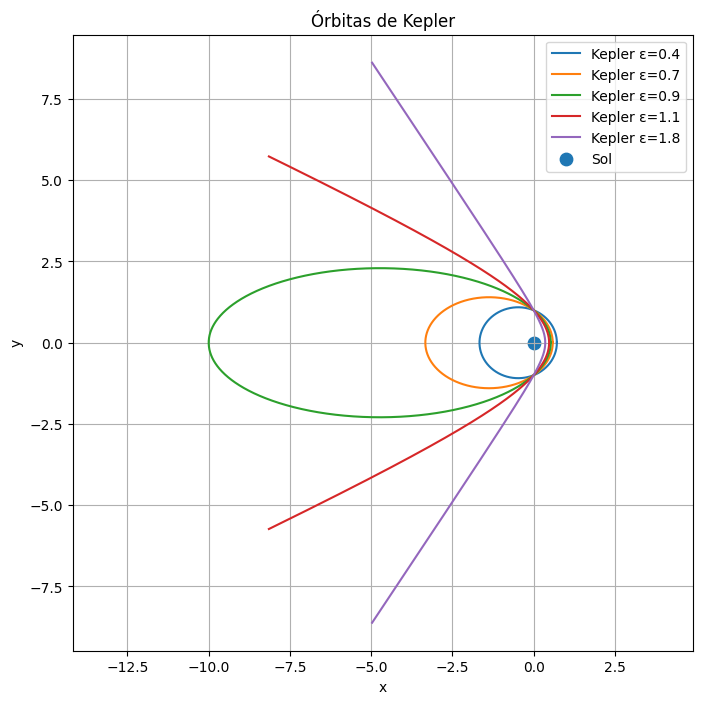

In [ ]:
eccentricidades = [0.4,0.7,0.9, 1.1, 1.8]

alpha = 1
delta = 0.01

tol_u = 1e-6

graficar_orbitas(
    eccentricidades=eccentricidades,
    alpha=alpha,
    r_kepler=r_kepler
)

# Modelo Relativista

A diferencia del modelo de kepler el sistema con correccion relativista no tiene una solucion analitica exacta, por lo que hay que recurrir a metodos numericos para obtener sus soluciones.

In [9]:
# ---------------------------------
# Sistema relativista
# ---------------------------------
def sistema(theta, y, alpha, delta):
    u, v = y

    du = v
    dv = 1/alpha + delta * u**2 - u

    return [du, dv]

Dado que no tenemos solucion exacta no sabemos el dominio de $\theta$ por lo que hay que obtenerlo numericamente.

In [4]:
# ---------------------------------
# Buscar hasta dónde integrar:
# cuando |u| < tolerancia
# ---------------------------------
def encontrar_theta_limite(eps, alpha, delta, tol_u, theta_max):
    u0 = (1 + eps) / alpha
    v0 = 0

    theta_test = np.linspace(0, theta_max, 20000)

    sol = solve_ivp(
        sistema,
        [0, theta_max],
        [u0, v0],
        t_eval=theta_test,
        args=(alpha, delta),
        rtol=1e-10,
        atol=1e-10
    )

    u_vals = sol.y[0]

    # primer punto donde u se acerca demasiado a 0
    idx = np.where(np.abs(u_vals) < tol_u)[0]

    if len(idx) == 0:
        # no llegó a zona peligrosa
        return theta_max

    return theta_test[idx[0]]


### Trayectoria

Apartir de los parametros, calcula el dominio, las soluciones en coordenadas polares y las convierte a cartesianas.

In [11]:
def trayectoria_relativista(
    eps,
    alpha,
    delta,
    tol_u,
    theta_max_busqueda,
    sistema,
    encontrar_theta_limite
):
    """
    Devuelve (x, y) para la órbita relativista.
    """

    u0 = (1 + eps) / alpha
    v0 = 0

    theta_lim = encontrar_theta_limite(
        eps,
        alpha,
        delta,
        tol_u,
        theta_max_busqueda
    )

    print(f"ε = {eps} -> theta límite ≈ {theta_lim:.6f}")

    # integración hacia adelante
    theta_pos = np.linspace(
        0,
        theta_lim,
        5000
    )

    sol_pos = solve_ivp(
        sistema,
        [0, theta_lim],
        [u0, v0],
        t_eval=theta_pos,
        args=(alpha, delta),
        rtol=1e-10,
        atol=1e-10
    )

    # integración hacia atrás
    theta_neg = np.linspace(
        0,
        -theta_lim,
        5000
    )

    sol_neg = solve_ivp(
        sistema,
        [0, -theta_lim],
        [u0, v0],
        t_eval=theta_neg,
        args=(alpha, delta),
        rtol=1e-10,
        atol=1e-10
    )

    # unir ambas ramas
    theta_total = np.concatenate((
        sol_neg.t[::-1],
        sol_pos.t[1:]
    ))

    u_total = np.concatenate((
        sol_neg.y[0][::-1],
        sol_pos.y[0][1:]
    ))

    # filtro de seguridad
    mask = np.abs(u_total) > tol_u

    theta_total = theta_total[mask]
    u_total = u_total[mask]

    r = 1 / u_total

    x = r * np.cos(theta_total)
    y = r * np.sin(theta_total)

    return x, y


In [54]:
def graficar_orbitas(
    eccentricidades,
    alpha,
    delta,
    tol_u,
    theta_max_busqueda,
    sistema,
    encontrar_theta_limite,
):

    plt.figure(figsize=(8, 8))

    xs_plot = []
    ys_plot = []

    for eps in eccentricidades:

        xr, yr = trayectoria_relativista(
            eps,
            alpha,
            delta,
            tol_u,
            theta_max_busqueda,
            sistema,
            encontrar_theta_limite
        )

        xs_plot.append(xr)
        ys_plot.append(yr)

        estilo = "--"

        plt.plot(
            xr,
            yr,
            estilo,
            label=f"Relativista ε={eps}"
        )

    # -----------------------------
    # Sol en el origen
    # -----------------------------
    plt.scatter(
        0,
        0,
        s=80,
        label="Sol"
    )

    xmin, xmax, ymin, ymax = (-15, 2, -4, 4)

    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

    plt.axis("equal")
    plt.grid(True)
    plt.legend()

    titulo = "Órbitas relativistas"

    plt.title(titulo)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

ε = 0.4 -> theta límite ≈ 3.141593
ε = 0.7 -> theta límite ≈ 3.141593
ε = 0.9 -> theta límite ≈ 3.141593


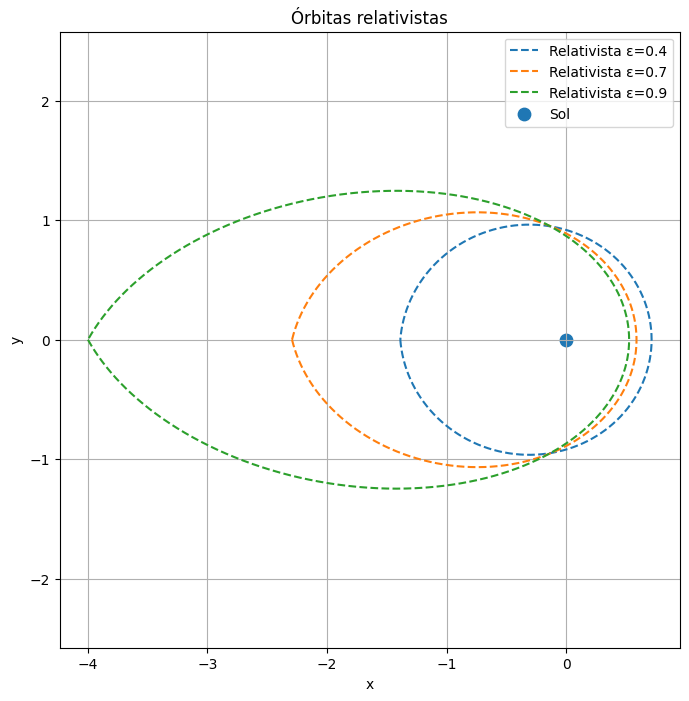

In [57]:
# prueba inicial simple

eccentricidades = [0.4,0.7,0.9]

alpha = 1
delta = 0.05

tol_u = 1e-6
theta_max_busqueda = 1*np.pi

graficar_orbitas(
    eccentricidades=eccentricidades,
    alpha=alpha,
    delta=delta,
    tol_u=tol_u,
    theta_max_busqueda=theta_max_busqueda,
    sistema=sistema,
    encontrar_theta_limite=encontrar_theta_limite,
)

# Comparacion final

Funcion que puede graficar ambos modelos o que puede generar uno seleccionado.

In [52]:
def graficar_orbitas(
    eccentricidades,
    alpha,
    delta,
    tol_u,
    theta_max_busqueda,
    r_kepler,
    sistema,
    encontrar_theta_limite,
    modo="comparacion"
):
    """
    modo:
        - 'kepler'
        - 'relativista'
        - 'comparacion'
    """

    plt.figure(figsize=(8, 8))

    xs_plot = []
    ys_plot = []

    for eps in eccentricidades:

        # -----------------------------
        # Solo Kepler
        # -----------------------------
        if modo in ["kepler", "comparacion"]:

            xk, yk = trayectoria_kepler(
                eps,
                alpha,
                r_kepler
            )

            xs_plot.append(xk)
            ys_plot.append(yk)

            plt.plot(
                xk,
                yk,
                label=f"Kepler ε={eps}"
            )

        # -----------------------------
        # Solo Relativista
        # -----------------------------
        if modo in ["relativista", "comparacion"]:

            xr, yr = trayectoria_relativista(
                eps,
                alpha,
                delta,
                tol_u,
                theta_max_busqueda,
                sistema,
                encontrar_theta_limite
            )

            xs_plot.append(xr)
            ys_plot.append(yr)

            estilo = "-"

            plt.plot(
                xr,
                yr,
                estilo,
                label=f"Relativista ε={eps}"
            )

    # -----------------------------
    # Sol en el origen
    # -----------------------------
    plt.scatter(
        0,
        0,
        s=80,
        label="Sol"
    )

    # -----------------------------
    # Ajuste automático de límites
    # -----------------------------
    xmin, xmax, ymin, ymax = (-15, 2, -4, 4)

    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

    plt.axis("equal")
    plt.grid(True)
    plt.legend()

    if modo == "kepler":
        titulo = "Órbitas de Kepler"
    elif modo == "relativista":
        titulo = "Órbitas relativistas"
    else:
        titulo = "Comparación: Kepler vs Relativista"

    plt.title(titulo)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

ε = 0.3 -> theta límite ≈ 9.425778


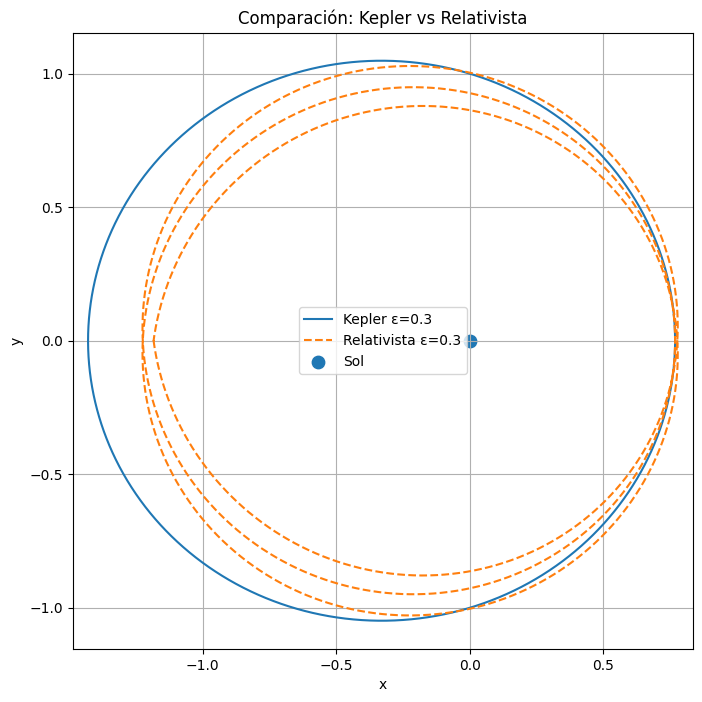

In [51]:
# prueba inicial simple

eccentricidades = [0.3]

alpha = 1
delta = 0.05

tol_u = 1e-6
theta_max_busqueda = 3*np.pi + 1e-3

graficar_orbitas(
    eccentricidades=eccentricidades,
    alpha=alpha,
    delta=delta,
    tol_u=tol_u,
    theta_max_busqueda=theta_max_busqueda,
    r_kepler = r_kepler,
    sistema=sistema,
    encontrar_theta_limite=encontrar_theta_limite,
)